---
# 🔏 Pengenalan Aksara Jawa 120 Kelas (Silabik)
## Handwritten Javanese Script Recognition — EfficientNet-B0
### Strategi Augmentasi Berbasis Preservasi Struktur pada Dataset Tidak Seimbang (IR 22.7x)

**Pipeline:**
1. Stratified Split 70:15:15
2. Integrasi Sub-folder Variations
3. Targeted Augmentasi Preservasi Struktur (non-geometris)
4. Weighted Loss Function

**Dataset:** Indonesian Local Script Characters (Mendeley Data, Telkom University)
**Total kelas:** 120 (6 vokal × 20 konsonan)
**Hardware:** NVIDIA GeForce RTX 3070 Ti (8GB VRAM) + AMD Ryzen 5 3600

---

In [1]:
# pip install torch torchvision tqdm pillow numpy matplotlib seaborn scikit-learn pandas

## ⚙️ Cell 1 — Setup & Konfigurasi Global

In [2]:
# =============================================================
# Cell 1: Setup, Hardware Check & Konfigurasi Global
# =============================================================
import os, shutil, random, copy, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torchvision
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from PIL import Image, ImageFilter, ImageEnhance
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, accuracy_score)
import seaborn as sns
warnings.filterwarnings('ignore')

# ─── KONFIGURASI GLOBAL ───────────────────────────────────────
SEED          = 42
DATASET_ROOT  = "D:/Doc-Coolyeah/00-AKADEMIK/SMT-6-Sem6/Computer Vision/Jawa/Jawa"
ALL_CLASS_DIR = os.path.join(DATASET_ROOT, "all_class")
VARIATIONS_DIR= os.path.join(DATASET_ROOT, "variations")
PREPARED_DIR  = "D:/Doc-Coolyeah/00-AKADEMIK/SMT-6-Sem6/Computer Vision/Jawa/prepared_data"

TRAIN_RATIO    = 0.70
VAL_RATIO      = 0.15   # TEST_RATIO = 0.15 (sisa)
AUGMENT_TARGET = 300    # Target gambar per kelas minoritas
BATCH_SIZE     = 32
NUM_WORKERS    = 4
NUM_EPOCHS     = 100
ES_PATIENCE    = 10     # Early Stopping patience
LR             = 1e-3

VOKAL_GROUPS = ['Vokal A','Vokal E','Vokal I','Vokal O','Vokal U','Vokal È']
VOKAL_PREFIX = {                           # untuk nama folder prepared_data
    'Vokal A':'A', 'Vokal E':'E', 'Vokal I':'I',
    'Vokal O':'O', 'Vokal U':'U', 'Vokal È':'Etaling'
}

# ─── REPRODUCIBILITY ─────────────────────────────────────────
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ─── HARDWARE ────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("🔍 SYSTEM CHECK — AKSARA JAWA 120-CLASS RECOGNITION")
print("="*60)
print(f"✅ PyTorch : {torch.__version__} | Torchvision: {torchvision.__version__}")
print(f"⚙️  Device  : {device.type.upper()}")
if device.type == 'cuda':
    print(f"🚀 GPU     : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"📊 VRAM    : {vram:.2f} GB")
print(f"⚙️  Batch   : {BATCH_SIZE} | Workers: {NUM_WORKERS}")
print(f"📁 Dataset : {DATASET_ROOT}")
print("="*60)


🔍 SYSTEM CHECK — AKSARA JAWA 120-CLASS RECOGNITION
✅ PyTorch : 2.12.0+cpu | Torchvision: 0.27.0+cpu
⚙️  Device  : CPU
⚙️  Batch   : 32 | Workers: 4
📁 Dataset : D:/Doc-Coolyeah/00-AKADEMIK/SMT-6-Sem6/Computer Vision/Jawa/Jawa


---
## 📊 Cell 2 — Exploratory Data Analysis (EDA)

✅ Total kelas: 120 | Expected: 120

📊 STATISTIK DISTRIBUSI all_class:
  Total gambar    : 12,191
  Max/kelas       : 695 → A_ya
  Min/kelas       : 21 → E_be
  Imbalance Ratio : 33.10x
  Median/kelas    : 22.0
  Mean/kelas      : 101.59
  Std             : 189.73

📊 RINGKASAN PER KELOMPOK VOKAL:
  Vokal A     : 20 kelas | 103-695 img/kelas | total 9,995
  Vokal E     : 20 kelas | 21-26 img/kelas | total 440
  Vokal I     : 20 kelas | 22-22 img/kelas | total 440
  Vokal O     : 20 kelas | 22-22 img/kelas | total 440
  Vokal U     : 20 kelas | 22-22 img/kelas | total 440
  Vokal È     : 20 kelas | 21-22 img/kelas | total 436


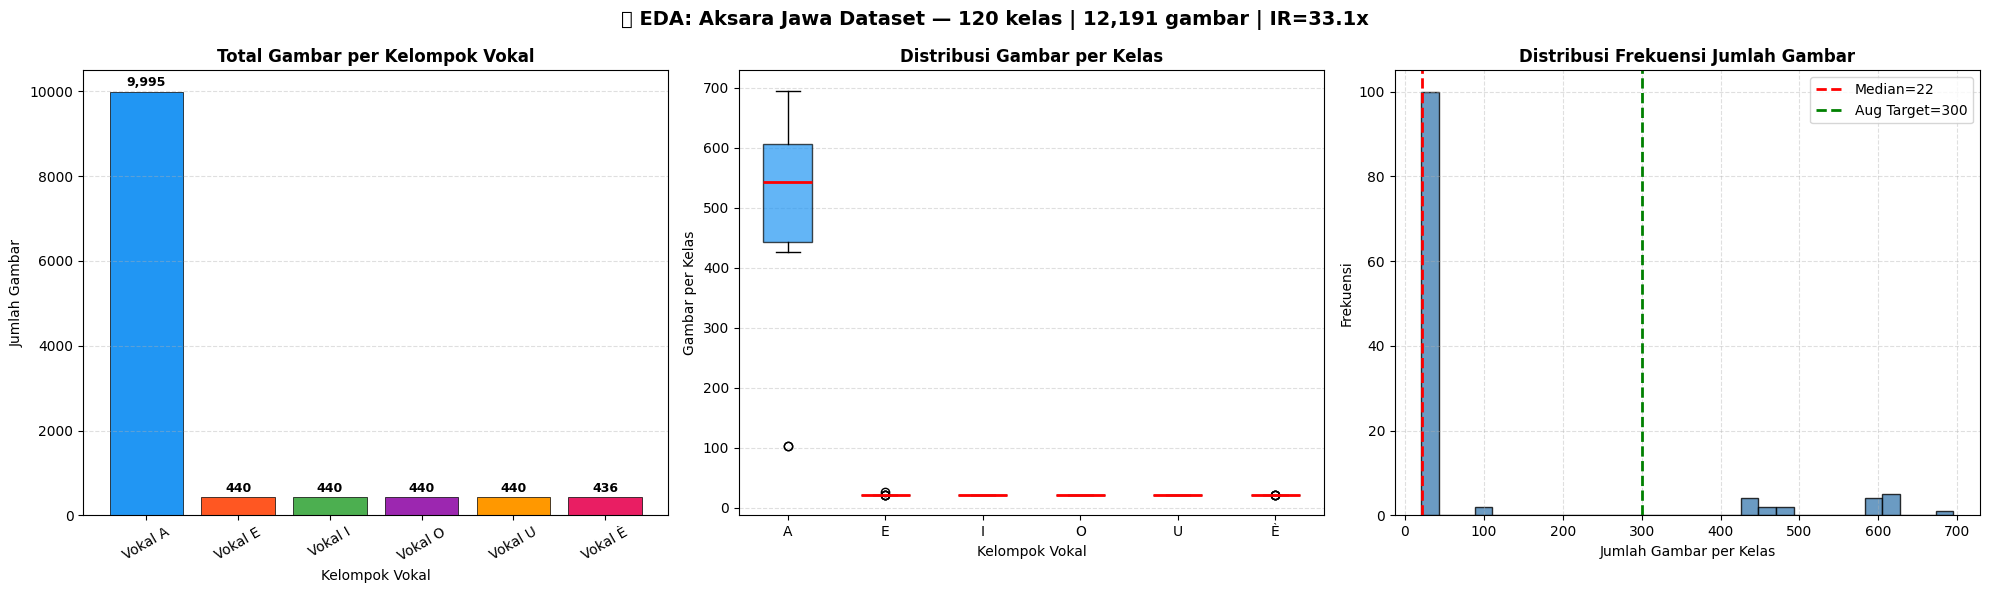

✅ Plot EDA disimpan: eda_distribution.png


In [3]:
# =============================================================
# Cell 2: EDA — Eksplorasi & Visualisasi Dataset
# =============================================================
import pandas as pd

# ─── INVENTARISASI SEMUA 120 KELAS ──────────────────────────
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp')

class_inventory = {}  # key: "PREFIX_consonant"  value: {vokal, konsonan, paths, count}

for vokal in VOKAL_GROUPS:
    vokal_dir = os.path.join(ALL_CLASS_DIR, vokal)
    if not os.path.isdir(vokal_dir):
        print(f"⚠️  Folder tidak ditemukan: {vokal_dir}")
        continue
    prefix = VOKAL_PREFIX[vokal]
    for konsonan in sorted(os.listdir(vokal_dir)):
        kons_dir = os.path.join(vokal_dir, konsonan)
        if not os.path.isdir(kons_dir):
            continue   # lewati file stray (misal Picsart_... di Vokal È)
        imgs = [os.path.join(kons_dir, f)
                for f in os.listdir(kons_dir)
                if f.lower().endswith(IMG_EXTS)]
        cls_key = f"{prefix}_{konsonan}"
        class_inventory[cls_key] = {
            'vokal': vokal, 'konsonan': konsonan,
            'prefix': prefix, 'paths': imgs, 'count': len(imgs)
        }

print(f"✅ Total kelas: {len(class_inventory)} | Expected: 120")

# ─── DATAFRAME EDA ─────────────────────────────────────────
df = pd.DataFrame([
    {'class': k, 'vokal': v['vokal'], 'prefix': v['prefix'],
     'konsonan': v['konsonan'], 'count': v['count']}
    for k, v in class_inventory.items()
])
df = df.sort_values(['prefix','konsonan']).reset_index(drop=True)

print(f"\n📊 STATISTIK DISTRIBUSI all_class:")
print(f"  Total gambar    : {df['count'].sum():,}")
print(f"  Max/kelas       : {df['count'].max()} → {df.loc[df['count'].idxmax(),'class']}")
print(f"  Min/kelas       : {df['count'].min()} → {df.loc[df['count'].idxmin(),'class']}")
print(f"  Imbalance Ratio : {df['count'].max()/df['count'].min():.2f}x")
print(f"  Median/kelas    : {df['count'].median():.1f}")
print(f"  Mean/kelas      : {df['count'].mean():.2f}")
print(f"  Std             : {df['count'].std():.2f}")

print(f"\n📊 RINGKASAN PER KELOMPOK VOKAL:")
for vokal in VOKAL_GROUPS:
    g = df[df['vokal']==vokal]
    if len(g):
        print(f"  {vokal:12s}: {len(g):2d} kelas | "
              f"{g['count'].min()}-{g['count'].max()} img/kelas | "
              f"total {g['count'].sum():,}")

# ─── VISUALISASI ────────────────────────────────────────────
COLORS = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#E91E63']
color_map = dict(zip(VOKAL_GROUPS, COLORS))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (1) Bar total per vokal group
grp = df.groupby('vokal')['count'].sum().reindex(VOKAL_GROUPS)
bars = axes[0].bar(grp.index, grp.values,
                   color=[color_map[v] for v in grp.index], edgecolor='black', lw=0.5)
axes[0].set_title('Total Gambar per Kelompok Vokal', fontweight='bold')
axes[0].set_xlabel('Kelompok Vokal'); axes[0].set_ylabel('Jumlah Gambar')
for b, val in zip(bars, grp.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{int(val):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30); axes[0].grid(axis='y', alpha=0.4, ls='--')

# (2) Boxplot distribusi per kelas
data_box = [df[df['vokal']==v]['count'].values for v in VOKAL_GROUPS]
bp = axes[1].boxplot(data_box, labels=[v.replace('Vokal ','') for v in VOKAL_GROUPS],
                     patch_artist=True, medianprops=dict(color='red', lw=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Distribusi Gambar per Kelas', fontweight='bold')
axes[1].set_xlabel('Kelompok Vokal'); axes[1].set_ylabel('Gambar per Kelas')
axes[1].grid(axis='y', alpha=0.4, ls='--')

# (3) Histogram jumlah gambar (log scale)
axes[2].hist(df['count'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[2].axvline(df['count'].median(), color='red', ls='--', lw=2, label=f"Median={df['count'].median():.0f}")
axes[2].axvline(AUGMENT_TARGET, color='green', ls='--', lw=2, label=f"Aug Target={AUGMENT_TARGET}")
axes[2].set_title('Distribusi Frekuensi Jumlah Gambar', fontweight='bold')
axes[2].set_xlabel('Jumlah Gambar per Kelas'); axes[2].set_ylabel('Frekuensi')
axes[2].legend(); axes[2].grid(alpha=0.4, ls='--')

ir = df['count'].max()/df['count'].min()
fig.suptitle(
    f'📊 EDA: Aksara Jawa Dataset — {len(df)} kelas | '
    f'{df["count"].sum():,} gambar | IR={ir:.1f}x',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot EDA disimpan: eda_distribution.png")


---
## 🔧 Pipeline Persiapan Data (4 Langkah)

### Cell 3 — Langkah 1: Stratified Split 70:15:15

In [4]:
# =============================================================
# Cell 3: Pipeline Langkah 1 — Stratified Split (70:15:15)
# =============================================================
print("="*60)
print("📂 LANGKAH 1: STRATIFIED SPLIT (70:15:15)")
print("="*60)

# Buat direktori output
for split in ['train','val','test']:
    os.makedirs(os.path.join(PREPARED_DIR, split), exist_ok=True)

def do_stratified_split(paths, train_r, val_r, seed):
    "Split per-kelas secara stratified, minimal 1 sampel per split."
    n = len(paths)
    if n < 3:                    # edge case: terlalu sedikit
        return paths, paths[:1], paths[:1]
    train_p, temp_p = train_test_split(paths, train_size=train_r, random_state=seed)
    val_size = val_r / (1 - train_r)
    if len(temp_p) < 2:
        return train_p, temp_p, temp_p
    val_p, test_p = train_test_split(temp_p, train_size=val_size, random_state=seed)
    return train_p, val_p, test_p

split_stats = {'train':0,'val':0,'test':0}
class_split_info = {}  # untuk cell berikutnya

for cls_key, info in tqdm(class_inventory.items(), desc="Stratified Split"):
    prefix   = info['prefix']
    konsonan = info['konsonan']
    folder_name = f"{prefix}_{konsonan}"          # e.g. "A_ba", "E_be", "Etaling_bè"

    train_p, val_p, test_p = do_stratified_split(
        info['paths'], TRAIN_RATIO, VAL_RATIO, SEED)

    class_split_info[cls_key] = {
        'folder_name': folder_name,
        'n_train_orig': len(train_p),
        'n_val': len(val_p),
        'n_test': len(test_p),
    }

    for split_name, split_paths in [('train',train_p),('val',val_p),('test',test_p)]:
        dst_dir = os.path.join(PREPARED_DIR, split_name, folder_name)
        os.makedirs(dst_dir, exist_ok=True)
        for src in split_paths:
            dst = os.path.join(dst_dir, os.path.basename(src))
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
        split_stats[split_name] += len(split_paths)

print(f"\n✅ Split selesai!")
for s, cnt in split_stats.items():
    print(f"  {s:6s}: {cnt:,} gambar")
print(f"  Total: {sum(split_stats.values()):,} gambar")

# Verifikasi: jumlah folder per split harus 120
for split in ['train','val','test']:
    n_folders = len([d for d in os.listdir(os.path.join(PREPARED_DIR, split))
                     if os.path.isdir(os.path.join(PREPARED_DIR, split, d))])
    print(f"  {split}: {n_folders} class folders (expected 120)")


📂 LANGKAH 1: STRATIFIED SPLIT (70:15:15)


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

### Cell 4 — Langkah 2: Integrasi Sub-folder Variations

In [ ]:
# =============================================================
# Cell 4: Pipeline Langkah 2 — Integrasi Sub-folder Variations
# =============================================================
print("="*60)
print("📂 LANGKAH 2: INTEGRASI SUB-FOLDER VARIATIONS → TRAINING SET")
print("="*60)

var_stats = {}

for konsonan in sorted(os.listdir(VARIATIONS_DIR)):
    var_dir = os.path.join(VARIATIONS_DIR, konsonan)
    if not os.path.isdir(var_dir):
        continue

    # Variations selalu dipetakan ke Vokal A
    target_folder = f"A_{konsonan}"
    target_train  = os.path.join(PREPARED_DIR, 'train', target_folder)
    if not os.path.exists(target_train):
        print(f"⚠️  Target tidak ditemukan: {target_folder}")
        continue

    var_imgs = [f for f in os.listdir(var_dir) if f.lower().endswith(IMG_EXTS)]
    copied = 0
    for img_name in var_imgs:
        src = os.path.join(var_dir, img_name)
        dst = os.path.join(target_train, f"var_{img_name}")
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
            copied += 1

    var_stats[konsonan] = copied
    print(f"  ✅ variations/{konsonan}: {copied} gambar → train/{target_folder}/")

total_var = sum(var_stats.values())
print(f"\n✅ Total gambar variations diintegrasikan: {total_var:,}")

# Update class_split_info dengan jumlah gambar setelah integrasi
for konsonan, cnt in var_stats.items():
    cls_key = f"A_{konsonan}"
    if cls_key in class_split_info:
        class_split_info[cls_key]['n_train_orig'] += cnt


### Cell 5 — Langkah 3a: Definisi Fungsi Augmentasi Preservasi Struktur

In [ ]:
# =============================================================
# Cell 5: Definisi Fungsi Augmentasi Berbasis Preservasi Struktur
# =============================================================
# Augmentasi yang DIIZINKAN  : fotometrik + morfologis minimal
# Augmentasi yang DILARANG   : rotasi, flip, shear, elastic distortion
# Justifikasi                : pasangan ha/la adalah cerminan horizontal,
#                              flip/rotasi akan merusak makna aksara Jawa

def structure_preserving_augment(img_pil, seed=None):
    \"\"\"
    Augmentasi berbasis preservasi struktur Aksara Jawa.
    Tidak menggunakan transformasi geometris yang mengubah makna aksara.

    Transformasi yang diizinkan:
      Fotometrik  : brightness, contrast, blur, noise, sharpen
      Morfologis  : dilation (MaxFilter), erosion (MinFilter)
      Spasial min : random crop + resize (max 10% tepi)
    \"\"\"
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed % (2**31))

    img = img_pil.copy()

    TRANSFORMS = [
        'brightness','contrast','blur','noise',
        'sharpen','dilation','erosion','crop_pad'
    ]
    chosen = random.sample(TRANSFORMS, random.randint(1, 3))

    for t in chosen:
        if t == 'brightness':
            img = ImageEnhance.Brightness(img).enhance(random.uniform(0.70, 1.30))

        elif t == 'contrast':
            img = ImageEnhance.Contrast(img).enhance(random.uniform(0.70, 1.30))

        elif t == 'blur':
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))

        elif t == 'noise':
            arr = np.array(img, dtype=np.float32)
            sigma = random.uniform(0.01, 0.05) * 255.0
            arr = np.clip(arr + np.random.normal(0, sigma, arr.shape), 0, 255).astype(np.uint8)
            img = Image.fromarray(arr)

        elif t == 'sharpen':
            img = ImageEnhance.Sharpness(img).enhance(random.uniform(1.2, 2.0))

        elif t == 'dilation':
            # MaxFilter mensimulasikan dilation morfologis (ukuran goresan lebih tebal)
            size = random.choice([3, 5])
            img = img.filter(ImageFilter.MaxFilter(size=size))

        elif t == 'erosion':
            # MinFilter mensimulasikan erosion morfologis (ukuran goresan lebih tipis)
            size = random.choice([3, 5])
            img = img.filter(ImageFilter.MinFilter(size=size))

        elif t == 'crop_pad':
            w, h = img.size
            max_c = 0.10    # max 10% dari tepi
            l = random.randint(0, max(1, int(w * max_c)))
            tp = random.randint(0, max(1, int(h * max_c)))
            r = random.randint(0, max(1, int(w * max_c)))
            b = random.randint(0, max(1, int(h * max_c)))
            left, upper = l, tp
            right = max(w - r, left + 1)
            lower = max(h - b, upper + 1)
            img = img.crop((left, upper, right, lower)).resize((w, h), Image.LANCZOS)

    return img


# ─── DEMO AUGMENTASI (VISUALISASI) ──────────────────────────
# Ambil sampel dari kelas minoritas pertama
sample_cls = [k for k in class_inventory if class_inventory[k]['vokal'] != 'Vokal A'][0]
sample_path = class_inventory[sample_cls]['paths'][0]
sample_img  = Image.open(sample_path).convert('RGB')

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
axes[0].imshow(sample_img); axes[0].set_title('Original', fontweight='bold'); axes[0].axis('off')

transform_labels = ['brightness','contrast','blur','noise','sharpen','dilation','erosion','crop_pad']
for i, t in enumerate(transform_labels, 1):
    img_copy = sample_img.copy()
    # Paksa transform tunggal untuk demo
    random.seed(i*13); np.random.seed(i*13)
    if t == 'brightness':
        demo = ImageEnhance.Brightness(img_copy).enhance(random.uniform(0.70,1.30))
    elif t == 'contrast':
        demo = ImageEnhance.Contrast(img_copy).enhance(random.uniform(0.70,1.30))
    elif t == 'blur':
        demo = img_copy.filter(ImageFilter.GaussianBlur(radius=1.2))
    elif t == 'noise':
        arr = np.array(img_copy, dtype=np.float32)
        arr = np.clip(arr + np.random.normal(0, 20, arr.shape), 0, 255).astype(np.uint8)
        demo = Image.fromarray(arr)
    elif t == 'sharpen':
        demo = ImageEnhance.Sharpness(img_copy).enhance(1.8)
    elif t == 'dilation':
        demo = img_copy.filter(ImageFilter.MaxFilter(size=3))
    elif t == 'erosion':
        demo = img_copy.filter(ImageFilter.MinFilter(size=3))
    elif t == 'crop_pad':
        w,h = img_copy.size
        demo = img_copy.crop((10, 10, w-10, h-10)).resize((w,h), Image.LANCZOS)
    axes[i].imshow(demo); axes[i].set_title(t, fontsize=9); axes[i].axis('off')

fig.suptitle(f'Demo Augmentasi Preservasi Struktur — {sample_cls}\n'
             '(Tidak ada rotasi/flip/shear)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('aug_demo.png', dpi=120, bbox_inches='tight'); plt.show()
print(f"✅ Demo augmentasi disimpan: aug_demo.png")


### Cell 6 — Langkah 3b: Eksekusi Augmentasi pada Kelas Minoritas

In [ ]:
# =============================================================
# Cell 6: Pipeline Langkah 3 — Eksekusi Targeted Augmentasi
# =============================================================
print("="*60)
print(f"📂 LANGKAH 3: TARGETED AUGMENTASI (target={AUGMENT_TARGET} gambar/kelas)")
print("="*60)
print("Hanya kelas dengan n_train < AUGMENT_TARGET yang diaugmentasi")
print("(Vokal A sudah di atas target, jadi tidak disentuh)\n")

aug_summary = {}

for folder_name in tqdm(sorted(os.listdir(os.path.join(PREPARED_DIR,'train'))),
                        desc="Augmentasi"):
    train_cls_dir = os.path.join(PREPARED_DIR, 'train', folder_name)
    if not os.path.isdir(train_cls_dir):
        continue

    existing = [f for f in os.listdir(train_cls_dir) if f.lower().endswith(IMG_EXTS)]
    n_exist  = len(existing)

    if n_exist >= AUGMENT_TARGET:
        aug_summary[folder_name] = {'orig': n_exist, 'added': 0, 'final': n_exist}
        continue

    n_needed  = AUGMENT_TARGET - n_exist
    aug_count = 0

    for i in range(n_needed):
        src_name = random.choice(existing)
        src_path = os.path.join(train_cls_dir, src_name)
        try:
            img     = Image.open(src_path).convert('RGB')
            aug_img = structure_preserving_augment(
                img, seed=SEED + i + abs(hash(folder_name)) % 9973)
            aug_path = os.path.join(train_cls_dir, f"aug_{i:04d}_{src_name}")
            aug_img.save(aug_path, quality=95)
            aug_count += 1
        except Exception as e:
            print(f"⚠️  Error {src_path}: {e}")

    aug_summary[folder_name] = {
        'orig': n_exist, 'added': aug_count, 'final': n_exist + aug_count}

# ─── RINGKASAN ───────────────────────────────────────────────
n_orig = sum(v['orig']  for v in aug_summary.values())
n_add  = sum(v['added'] for v in aug_summary.values())
n_fin  = sum(v['final'] for v in aug_summary.values())
n_augmented_classes = sum(1 for v in aug_summary.values() if v['added'] > 0)
n_skipped_classes   = sum(1 for v in aug_summary.values() if v['added'] == 0)

print(f"\n✅ Augmentasi selesai!")
print(f"  Gambar original training   : {n_orig:,}")
print(f"  Gambar augmentasi ditambah : {n_add:,}")
print(f"  Total training final       : {n_fin:,}")
print(f"  Kelas diaugmentasi         : {n_augmented_classes} kelas (vokal non-A)")
print(f"  Kelas dilewati             : {n_skipped_classes} kelas (vokal A, sudah >= {AUGMENT_TARGET})")

# Plot distribusi akhir training
final_counts = [v['final'] for v in aug_summary.values()]
plt.figure(figsize=(10,4))
plt.hist(final_counts, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(AUGMENT_TARGET, color='red', ls='--', lw=2, label=f'Target={AUGMENT_TARGET}')
plt.title('Distribusi Jumlah Gambar Training per Kelas (Setelah Augmentasi)', fontweight='bold')
plt.xlabel('Jumlah Gambar per Kelas'); plt.ylabel('Frekuensi'); plt.legend()
plt.grid(alpha=0.4, ls='--'); plt.tight_layout()
plt.savefig('aug_distribution_final.png', dpi=120, bbox_inches='tight'); plt.show()


### Cell 7 — Langkah 4: Kalkulasi Class Weights untuk Weighted Loss

In [ ]:
# =============================================================
# Cell 7: Pipeline Langkah 4 — Weighted Loss (Class Weights)
# =============================================================
print("="*60)
print("📂 LANGKAH 4: KALKULASI CLASS WEIGHTS UNTUK WEIGHTED LOSS")
print("="*60)

train_dir    = os.path.join(PREPARED_DIR, 'train')
class_folders = sorted([d for d in os.listdir(train_dir)
                         if os.path.isdir(os.path.join(train_dir, d))])

# Kumpulkan label seluruh gambar training
all_labels = []
for idx, cls_f in enumerate(class_folders):
    cls_path = os.path.join(train_dir, cls_f)
    n_imgs   = len([f for f in os.listdir(cls_path) if f.lower().endswith(IMG_EXTS)])
    all_labels.extend([idx] * n_imgs)

all_labels_arr = np.array(all_labels)
classes_arr    = np.unique(all_labels_arr)

class_weights     = compute_class_weight('balanced', classes=classes_arr, y=all_labels_arr)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"✅ Class weights dihitung untuk {len(class_weights)} kelas")
print(f"  Weight min : {class_weights.min():.4f}  (kelas paling banyak datanya)")
print(f"  Weight max : {class_weights.max():.4f}  (kelas paling sedikit datanya)")
print(f"  Weight mean: {class_weights.mean():.4f}")
print(f"  Weight ratio: {class_weights.max()/class_weights.min():.2f}x")
print(f"\n  class_weights_tensor.shape = {class_weights_tensor.shape}")
print(f"  Akan diterapkan sebagai bobot pada nn.CrossEntropyLoss")


---
## 🧠 Pelatihan Model

### Cell 8 — Persiapan Dataset & DataLoader

In [ ]:
# =============================================================
# Cell 8: Persiapan Dataset & DataLoader
# =============================================================
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transformasi: augmentasi offline sudah selesai di langkah 3,
# sehingga training hanya memerlukan resize + normalisasi ImageNet
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

image_datasets = {
    'train': datasets.ImageFolder(os.path.join(PREPARED_DIR,'train'), train_transforms),
    'val'  : datasets.ImageFolder(os.path.join(PREPARED_DIR,'val'),   eval_transforms),
    'test' : datasets.ImageFolder(os.path.join(PREPARED_DIR,'test'),  eval_transforms),
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE,
                  shuffle=(x=='train'), num_workers=NUM_WORKERS,
                  pin_memory=True, persistent_workers=(NUM_WORKERS>0))
    for x in ['train','val','test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train','val','test']}
class_names   = image_datasets['train'].classes
num_classes   = len(class_names)

# Peta kelas ke vokal group (untuk evaluasi per kelompok nanti)
def infer_vokal(cls_name):
    if   cls_name.startswith('A_'):       return 'Vokal A'
    elif cls_name.startswith('E_'):       return 'Vokal E'
    elif cls_name.startswith('I_'):       return 'Vokal I'
    elif cls_name.startswith('O_'):       return 'Vokal O'
    elif cls_name.startswith('U_'):       return 'Vokal U'
    elif cls_name.startswith('Etaling_'): return 'Vokal È'
    return 'Unknown'

vokal_of_class = {cls: infer_vokal(cls) for cls in class_names}

print("="*60)
print("📂 DATASET DIMUAT")
print("="*60)
print(f"  Jumlah kelas : {num_classes} (expected 120)")
print(f"  Train  : {dataset_sizes['train']:,} gambar")
print(f"  Val    : {dataset_sizes['val']:,} gambar")
print(f"  Test   : {dataset_sizes['test']:,} gambar")
print(f"  Total  : {sum(dataset_sizes.values()):,} gambar")

# Verifikasi distribusi kelas dari dataset
class_dist = Counter(image_datasets['train'].targets)
vokal_totals = defaultdict(int)
for idx, cnt in class_dist.items():
    vokal_totals[infer_vokal(class_names[idx])] += cnt
print(f"\n  Distribusi training per kelompok vokal:")
for vg in VOKAL_GROUPS:
    print(f"    {vg:12s}: {vokal_totals[vg]:,} gambar")


### Cell 9 — Arsitektur EfficientNet-B0

In [ ]:
# =============================================================
# Cell 9: Arsitektur Model — EfficientNet-B0 (Transfer Learning)
# =============================================================
print("="*60)
print("🧠 INISIALISASI EFFICIENTNET-B0 (TRANSFER LEARNING)")
print("="*60)

# Load pretrained EfficientNet-B0 (ImageNet weights)
weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
model   = models.efficientnet_b0(weights=weights)

# Modifikasi classifier head untuk 120 kelas
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

# Hitung total parameter
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ EfficientNet-B0 dimuat dengan bobot ImageNet")
print(f"⚙️  Classifier head diubah: {num_ftrs} → {num_classes} kelas")
print(f"📊 Total parameter    : {total_params:,} (~{total_params/1e6:.1f}M)")
print(f"📊 Trainable parameter: {trainable_params:,}")
print(f"🚀 Model posisi       : {device.type.upper()}")

# Loss Function dengan Class Weights (Langkah 4 pipeline)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print(f"\n✅ Loss: CrossEntropyLoss(weight=class_weights_tensor)")
print(f"   class_weights_tensor.min={class_weights_tensor.min():.4f}  "
      f"max={class_weights_tensor.max():.4f}")


### Cell 10 — Training Engine (2-Phase Fine-tuning)

In [ ]:
# =============================================================
# Cell 10: Training Engine — 2-Phase Fine-tuning
# =============================================================
# Phase 1 (epoch 1-10) : Freeze backbone, train classifier head saja
# Phase 2 (epoch 11++) : Unfreeze semua, fine-tune penuh
print("="*60)
print("🚀 MEMULAI TRAINING ENGINE (2-Phase Fine-tuning)")
print("="*60)

def freeze_backbone(m):
    \"\"\"Freeze semua layer kecuali classifier head.\"\"\"
    for name, param in m.named_parameters():
        param.requires_grad = ('classifier' in name)

def unfreeze_all(m):
    for param in m.parameters():
        param.requires_grad = True

def train_model(model, criterion, num_epochs=NUM_EPOCHS, patience=ES_PATIENCE):
    since   = time.time()
    history = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}

    best_wts    = copy.deepcopy(model.state_dict())
    best_acc    = 0.0
    no_improve  = 0
    phase2_started = False

    # Phase 1: hanya classifier
    freeze_backbone(model)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, verbose=True)

    for epoch in range(num_epochs):
        # Masuk Phase 2 setelah epoch ke-10
        if epoch == 10 and not phase2_started:
            print("\n🔓 PHASE 2: Unfreeze semua layer — fine-tuning penuh")
            unfreeze_all(model)
            optimizer = optim.AdamW(model.parameters(), lr=LR/10, weight_decay=5e-4)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max', factor=0.5, patience=3, verbose=True)
            phase2_started = True

        print(f"\n🔄 Epoch {epoch+1}/{num_epochs}  "
              f"{'[Phase 1: Head Only]' if not phase2_started else '[Phase 2: Full Fine-tune]'}")
        print("-"*50)

        for phase in ['train','val']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_corrects = 0.0, 0

            for inputs, labels in tqdm(dataloaders[phase],
                                       desc=f"{phase.capitalize()} Phase", leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss     = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward(); optimizer.step()

                running_loss      += loss.item() * inputs.size(0)
                running_corrects  += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]
            print(f"📊 [{phase.upper():5s}] Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                scheduler.step(epoch_acc)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    no_improve = 0
                    print(f"  🏆 Best model diperbarui! Val Acc: {best_acc:.4f}")
                else:
                    no_improve += 1

        print(f"⚙️  Early Stopping: {no_improve}/{patience}")
        if no_improve >= patience:
            print(f"\n⚠️  Early Stopping aktif di epoch {epoch+1}.")
            break

    elapsed = time.time() - since
    print(f"\n✅ Training selesai: {elapsed//60:.0f}m {elapsed%60:.0f}s")
    print(f"🏆 Best Val Accuracy: {best_acc:.4f}")
    model.load_state_dict(best_wts)
    return model, history

model, history = train_model(model, criterion)


### Cell 11 — Visualisasi Kurva Training

In [ ]:
# =============================================================
# Cell 11: Visualisasi Kurva Training
# =============================================================
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(epochs_range, history['train_loss'], 'r-o', ms=4, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'b-o', ms=4, label='Val Loss')
axes[0].axvline(10, color='gray', ls=':', lw=1.5, label='Phase 2 Start')
axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(ls='--', alpha=0.6); axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], 'g-o', ms=4, label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'],   'm-o', ms=4, label='Val Acc')
axes[1].axvline(10, color='gray', ls=':', lw=1.5, label='Phase 2 Start')
axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].grid(ls='--', alpha=0.6); axes[1].legend()

fig.suptitle(
    'EfficientNet-B0: Kurva Training — Aksara Jawa 120 Kelas\n'
    '(2-Phase Fine-tuning | Structure-Preserving Aug | Weighted Loss)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight'); plt.show()
print("✅ Plot kurva training disimpan: training_curves.png")


---
## 📈 Evaluasi

### Cell 12 — Evaluasi Keseluruhan (Test Set)

In [ ]:
# =============================================================
# Cell 12: Evaluasi Keseluruhan — Test Set
# =============================================================
print("="*60)
print("🎯 EVALUASI TEST SET — KESELURUHAN")
print("="*60)

model.eval()
y_true_all, y_pred_all, all_outputs = [], [], []

with torch.no_grad():
    for inputs, labels in tqdm(dataloaders['test'], desc="Inferensi Test Set"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true_all.extend(labels.cpu().numpy())
        y_pred_all.extend(preds.cpu().numpy())
        all_outputs.append(outputs.cpu())

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_all)
all_out_tensor = torch.cat(all_outputs, dim=0)

# ─── TOP-1 & TOP-5 ──────────────────────────────────────────
top1_acc = accuracy_score(y_true, y_pred) * 100
k = min(5, num_classes)
_, topk_preds = torch.topk(all_out_tensor, k, dim=1)
top5_correct  = sum(y_true[i] in topk_preds[i] for i in range(len(y_true)))
top5_acc      = top5_correct / len(y_true) * 100

# ─── PRECISION / RECALL / F1 ─────────────────────────────────
prec_mac, rec_mac, f1_mac, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro',    zero_division=0)
prec_wt,  rec_wt,  f1_wt,  _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0)

print(f"\n📊 HASIL EVALUASI KESELURUHAN:")
print(f"  Top-1 Accuracy  : {top1_acc:.2f}%")
print(f"  Top-{k} Accuracy  : {top5_acc:.2f}%")
print(f"\n  Macro   — Precision: {prec_mac:.4f} | Recall: {rec_mac:.4f} | F1: {f1_mac:.4f}")
print(f"  Weighted — Precision: {prec_wt:.4f}  | Recall: {rec_wt:.4f}  | F1: {f1_wt:.4f}")
print(f"\n  Total test samples: {len(y_true)}")


### Cell 13 — Evaluasi Per Kelompok Vokal
> **Kontribusi analitis utama:** melaporkan metrik secara terpisah antara kelas mayoritas (Vokal A) dan minoritas (Vokal non-A).

In [ ]:
# =============================================================
# Cell 13: Evaluasi Per Kelompok Vokal (Kontribusi Analisis Utama)
# =============================================================
print("="*60)
print("📊 EVALUASI PER KELOMPOK VOKAL")
print("="*60)
print("(Vokal A = mayoritas | Vokal non-A = minoritas)")

results_per_group = {}

for vokal_group in VOKAL_GROUPS:
    # Ambil indeks kelas yang termasuk grup ini
    group_class_indices = [i for i, cls in enumerate(class_names)
                           if vokal_of_class[cls] == vokal_group]
    if not group_class_indices:
        continue

    # Filter sampel test set yang termasuk grup ini
    mask = np.isin(y_true, group_class_indices)
    if mask.sum() == 0:
        continue

    y_t = y_true[mask]
    y_p = y_pred[mask]

    acc  = accuracy_score(y_t, y_p) * 100
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_t, y_p, average='macro', zero_division=0)

    results_per_group[vokal_group] = {
        'n_classes': len(group_class_indices),
        'n_samples': int(mask.sum()),
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1_macro' : f1,
    }
    print(f"\n  {vokal_group:12s} ({len(group_class_indices):2d} kelas | {int(mask.sum()):4d} sampel):")
    print(f"    Accuracy : {acc:.2f}%")
    print(f"    Precision: {prec:.4f} | Recall: {rec:.4f} | F1-macro: {f1:.4f}")

# ─── PLOT PERBANDINGAN ────────────────────────────────────────
groups   = list(results_per_group.keys())
f1_vals  = [results_per_group[g]['f1_macro']  for g in groups]
acc_vals = [results_per_group[g]['accuracy']  for g in groups]
COLORS_G = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#E91E63']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar1 = axes[0].bar(groups, f1_vals, color=COLORS_G[:len(groups)], edgecolor='black', lw=0.5)
axes[0].set_title('F1-score Macro per Kelompok Vokal', fontweight='bold')
axes[0].set_ylabel('F1-score Macro'); axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=30); axes[0].grid(axis='y', alpha=0.4, ls='--')
for b, v in zip(bar1, f1_vals):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

bar2 = axes[1].bar(groups, acc_vals, color=COLORS_G[:len(groups)], edgecolor='black', lw=0.5)
axes[1].set_title('Accuracy per Kelompok Vokal', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)'); axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=30); axes[1].grid(axis='y', alpha=0.4, ls='--')
for b, v in zip(bar2, acc_vals):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Evaluasi Per Kelompok Vokal — Vokal A (Mayoritas) vs Vokal Non-A (Minoritas)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_per_vokal_group.png', dpi=150, bbox_inches='tight'); plt.show()


### Cell 14 — Confusion Matrix & Top-10 Pasangan Konfusif

In [ ]:
# =============================================================
# Cell 14: Confusion Matrix & Top-10 Pasangan Karakter Konfusif
# =============================================================
print("="*60)
print("📊 CONFUSION MATRIX & ANALISIS KARAKTER KONFUSIF")
print("="*60)

cm = confusion_matrix(y_true, y_pred)

# ─── HEATMAP (sub-sample: tampilkan hanya blok 20x20 per vokal A) ──
# Untuk 120x120 matrix, tampilkan dalam bentuk agregat vokal
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# (1) Normalized confusion matrix (heatmap kecil — per vokal group)
cm_vokal = np.zeros((len(VOKAL_GROUPS), len(VOKAL_GROUPS)), dtype=float)
group_idx = {g: i for i, g in enumerate(VOKAL_GROUPS)}
for true_cls, pred_cls, _ in zip(
    [class_names[t] for t in y_true],
    [class_names[p] for p in y_pred],
    range(len(y_true))
):
    gi_true = group_idx.get(vokal_of_class[true_cls], -1)
    gi_pred = group_idx.get(vokal_of_class[pred_cls], -1)
    if gi_true >= 0 and gi_pred >= 0:
        cm_vokal[gi_true, gi_pred] += 1

# Normalize per baris
cm_vokal_norm = cm_vokal / cm_vokal.sum(axis=1, keepdims=True)

sns.heatmap(cm_vokal_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[v.replace('Vokal ','') for v in VOKAL_GROUPS],
            yticklabels=[v.replace('Vokal ','') for v in VOKAL_GROUPS],
            ax=axes[0], linewidths=0.5, linecolor='gray',
            annot_kws={'size':11,'weight':'bold'})
axes[0].set_title('Confusion Matrix (Vokal Group Level, Normalized)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Ground Truth')

# (2) Top-10 pasangan konfusif
off_diag_indices = [(i, j) for i in range(num_classes)
                    for j in range(num_classes) if i != j]
confused_pairs   = sorted(off_diag_indices, key=lambda x: cm[x[0], x[1]], reverse=True)[:10]

pair_labels = [f"{class_names[i]}\n→ {class_names[j]}" for i, j in confused_pairs]
pair_counts  = [cm[i, j] for i, j in confused_pairs]
pair_colors  = [COLORS[VOKAL_GROUPS.index(vokal_of_class[class_names[i]])]
                for i, j in confused_pairs]

axes[1].barh(pair_labels[::-1], pair_counts[::-1], color=pair_colors[::-1], edgecolor='black', lw=0.5)
axes[1].set_title('Top-10 Pasangan Karakter Paling Konfusif', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Jumlah Kesalahan Klasifikasi')
axes[1].grid(axis='x', alpha=0.4, ls='--')

fig.suptitle('Analisis Kesalahan Klasifikasi — Aksara Jawa 120 Kelas', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_analysis.png', dpi=150, bbox_inches='tight'); plt.show()

print("\n📊 Top-10 Pasangan Konfusif:")
print(f"  {'Kelas Benar':25s} → {'Diprediksi sbg':25s}  {'N Salah':>8s}  Vokal")
print("  " + "-"*70)
for i, j in confused_pairs:
    print(f"  {class_names[i]:25s} → {class_names[j]:25s}  "
          f"{cm[i,j]:>8d}  {vokal_of_class[class_names[i]]}")


---
## 💾 Simpan Model & Ringkasan

In [ ]:
# =============================================================
# Cell 15: Simpan Model & Ringkasan Akhir
# =============================================================
save_dir = "D:/Doc-Coolyeah/00-AKADEMIK/SMT-6-Sem6/Computer Vision/Tubes"
os.makedirs(save_dir, exist_ok=True)

# Simpan state dict (lebih portabel dibanding full model)
model_path = os.path.join(save_dir, "efficientnet_b0_aksara_jawa_120class.pth")
torch.save({
    'model_state_dict'  : model.state_dict(),
    'class_names'       : class_names,
    'vokal_of_class'    : vokal_of_class,
    'num_classes'       : num_classes,
    'train_history'     : history,
    'config': {
        'architecture'    : 'EfficientNet-B0',
        'pretrained'      : 'ImageNet1K_V1',
        'input_size'      : (224, 224),
        'augment_strategy': 'Structure-Preserving (non-geometric)',
        'augment_target'  : AUGMENT_TARGET,
        'train_ratio'     : TRAIN_RATIO,
        'val_ratio'       : VAL_RATIO,
        'seed'            : SEED,
    }
}, model_path)

print("="*60)
print("✅ MODEL DISIMPAN")
print("="*60)
print(f"  Path : {model_path}")
print(f"  Size : {os.path.getsize(model_path)/1e6:.1f} MB")

print("\n" + "="*60)
print("📋 RINGKASAN AKHIR PENELITIAN")
print("="*60)
print(f"  Arsitektur     : EfficientNet-B0 (Transfer Learning ImageNet)")
print(f"  Jumlah kelas   : {num_classes} kelas silabik Aksara Jawa")
print(f"  Dataset        : Indonesian Local Script Characters (Mendeley)")
print(f"  Imbalance Ratio: ~22.7x (sebelum pipeline)")
print(f"\n  Pipeline yang diterapkan:")
print(f"    1. Stratified Split 70:15:15 per kelas")
print(f"    2. Integrasi {sum(var_stats.values())} gambar dari sub-folder variations")
print(f"    3. Structure-Preserving Augmentation (target {AUGMENT_TARGET}/kelas)")
print(f"    4. Weighted CrossEntropyLoss")
print(f"\n  Hasil Evaluasi Test Set:")
print(f"    Top-1 Accuracy : {top1_acc:.2f}%")
print(f"    F1 Macro       : {f1_mac:.4f}")
print(f"    F1 Weighted    : {f1_wt:.4f}")
print(f"\n  Evaluasi Per Kelompok Vokal (F1 Macro):")
for g, r in results_per_group.items():
    is_majority = "★ mayoritas" if g == "Vokal A" else "  minoritas"
    print(f"    {g:12s} [{is_majority}]: {r['f1_macro']:.4f}")
print("="*60)
